In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
Df_Medibuddy_DataPrice = pd.read_excel('Medibuddy_Insurance_DataPrice.xlsx')

In [5]:
Df_Medibuddy_DataPrice.head()

,Policy no.,age,sex,bmi,charges in INR
0,PLC156898,19,female,27.900,16884.92400
1,PLC156907,18,male,33.770,1725.55230
2,PLC156916,28,male,33.000,4449.46200
3,PLC156925,33,male,22.705,21984.47061
4,PLC156934,32,male,28.880,3866.85520


In [6]:
Df_Medibuddy_DataPrice.isnull().sum()

Policy no.        0
age               0
sex               0
bmi               0
charges in INR    0
dtype: int64

In [7]:
Df_Medibuddy_DataPrice.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Policy no.      1338 non-null   object 
 1   age             1338 non-null   int64  
 2   sex             1338 non-null   object 
 3   bmi             1338 non-null   float64
 4   charges in INR  1338 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 52.4+ KB


In [8]:
Df_Medibuddy_PersonalInfo = pd.read_excel('MedibuddyInsurancedatapersonal_details.xlsx')

In [9]:
Df_Medibuddy_PersonalInfo.head()

,Policy no.,children,smoker,region
0,PLC157006,0,no,southwest
1,PLC157033,1,no,southwest
2,PLC157060,0,no,southwest
3,PLC157087,1,no,southwest
4,PLC157186,5,no,southwest


In [10]:
Df_Medibuddy_PersonalInfo.isnull().sum()

Policy no.    0
children      0
smoker        0
region        0
dtype: int64

In [13]:
df_combined = Df_Medibuddy_DataPrice.merge(Df_Medibuddy_PersonalInfo, on='Policy no.', how='left')

In [14]:
df_combined.head()

,Policy no.,age,sex,bmi,charges in INR,children,smoker,region
0,PLC156898,19,female,27.900,16884.92400,0,yes,southwest
1,PLC156907,18,male,33.770,1725.55230,1,no,southeast
2,PLC156916,28,male,33.000,4449.46200,3,no,southeast
3,PLC156925,33,male,22.705,21984.47061,0,no,northwest
4,PLC156934,32,male,28.880,3866.85520,0,no,northwest


In [15]:
df_combined.drop('Policy no.',axis=1,inplace=True)

In [18]:
df_combined.describe(include='all')

,age,sex,bmi,charges in INR,children,smoker,region
count,1338.000000,1338,1338.000000,1338.000000,1338.000000,1338,1338
unique,NaN,2,NaN,NaN,NaN,2,4
top,NaN,male,NaN,NaN,NaN,no,southeast
freq,NaN,676,NaN,NaN,NaN,1064,364
mean,39.207025,NaN,30.663397,13270.422265,1.094918,NaN,NaN
std,14.049960,NaN,6.098187,12110.011237,1.205493,NaN,NaN
min,18.000000,NaN,15.960000,1121.873900,0.000000,NaN,NaN
25%,27.000000,NaN,26.296250,4740.287150,0.000000,NaN,NaN
50%,39.000000,NaN,30.400000,9382.033000,1.000000,NaN,NaN
75%,51.000000,NaN,34.693750,16639.912515,2.000000,NaN,NaN


In [19]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   sex             1338 non-null   object 
 2   bmi             1338 non-null   float64
 3   charges in INR  1338 non-null   float64
 4   children        1338 non-null   int64  
 5   smoker          1338 non-null   object 
 6   region          1338 non-null   object 
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


# Ques_1: Does gender matter as a constraint for extending policies?

In [20]:
# Compare average insurance charges by gender. 
# If one gender consistently claims much higher amounts, insurers may treat it as a risk segmentation factor

df_combined.groupby('sex')['charges in INR'].mean()

sex
female    12569.578844
male      13956.751178
Name: charges in INR, dtype: float64

In [21]:
df_combined.groupby('sex')['charges in INR'].describe()


,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
female,662.0,12569.578844,11128.703801,1607.5101,4885.1587,9412.96250,14454.691825,63770.42801
male,676.0,13956.751178,12971.025915,1121.8739,4619.1340,9369.61575,18989.590250,62592.87309


In [ ]:
# Males have slightly higher mean and higher variability (std)
# While males show higher average claims, the difference is not substantial

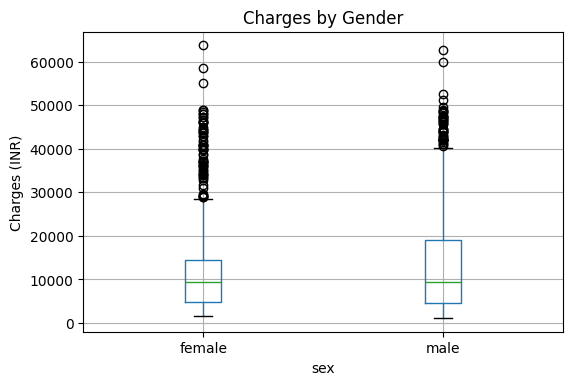

In [ ]:
df_combined.boxplot(column='charges in INR', by='sex', figsize=(6,4))
plt.title('Charges by Gender')
plt.suptitle('')
plt.ylabel('Charges (INR)')
plt.show()

In [ ]:
# Distributions overlap heavily, and medians are nearly identical
# Gender should not be treated as a constraint for extending insurance policies.
# At most, it can be a minor pricing consideration, but not a policy eligibility factor.

# Ques_2: What is the average amount spent per policy? - Overall mean insurance charge

In [ ]:
df_combined['charges in INR'].mean()
# Mean gives expected claim cost per policyholder

np.float64(13270.422265141257)

In [ ]:
df_combined['charges in INR'].median()
# Median helps detect outliers (very high claims)

np.float64(9382.033)

In [ ]:
# Mean is significantly higher than median → presence of high-value outlier claims.
# Most customers claim around ₹9–10K, but a few large claims pull the average upward

# Conclusion:
# The company spends ~₹13,270 per policy on average
# Median should be used for typical customer cost
# Mean helps in financial provisioning.

# Ques_3: Should policies differ by geographic location?

In [26]:
df_combined.groupby('region')['charges in INR'].mean().sort_values(ascending=False)


region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges in INR, dtype: float64

In [ ]:
# Customer distribution is almost equal across regions

In [27]:
df_combined['region'].value_counts()


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [ ]:
# Southeast region has noticeably higher claim amounts. 
# Since sample sizes are balanced, this difference is reliable and not due to bias

# Conclusion:
# Yes, the company should consider region-based pricing or risk loading, 
# especially for the Southeast region, as claims are consistently higher there


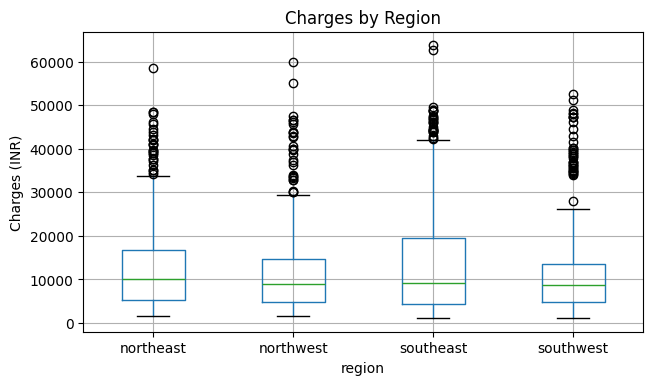

In [28]:
df_combined.boxplot(column='charges in INR', by='region', figsize=(7,4))
plt.title('Charges by Region')
plt.suptitle('')
plt.ylabel('Charges (INR)')
plt.show()


# Ques_4: Does number of dependents affect claim amount?

In [29]:
df_combined.groupby('children')['charges in INR'].mean()


children
0    12365.975602
1    12731.171832
2    15073.563734
3    15355.318367
4    13850.656311
5     8786.035247
Name: charges in INR, dtype: float64

In [ ]:
# Claims increase steadily from 0 to 3 children 
# Peak around: 2 children: ₹15,074 3 children: ₹15,355
# Drop seen for 4–5 children (likely due to small sample size)

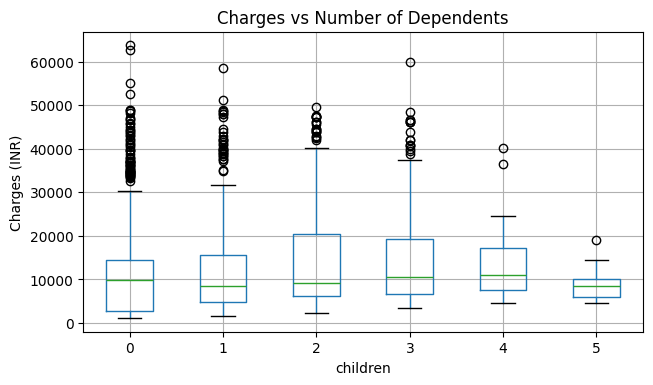

In [30]:
df_combined.boxplot(column='charges in INR', by='children', figsize=(7,4))
plt.title('Charges vs Number of Dependents')
plt.suptitle('')
plt.ylabel('Charges (INR)')
plt.show()


In [ ]:
# Families with more dependents tend to file higher claims.The trend is logical due to increased healthcare utilization.
# Dependents should be considered a risk and pricing factor.

# Ques_5: Does BMI help predict insurance claims?

In [31]:
df_combined[['bmi', 'charges in INR']].corr()


,bmi,charges in INR
bmi,1.000000,0.198341
charges in INR,0.198341,1.000000


In [ ]:
# Correlation between BMI and charges (0.198) indicates a weak positive relationship
# Higher BMI is associated with higher claims, but the relationship is not strong. 
# BMI alone cannot predict claims accurately, but it adds incremental risk information.

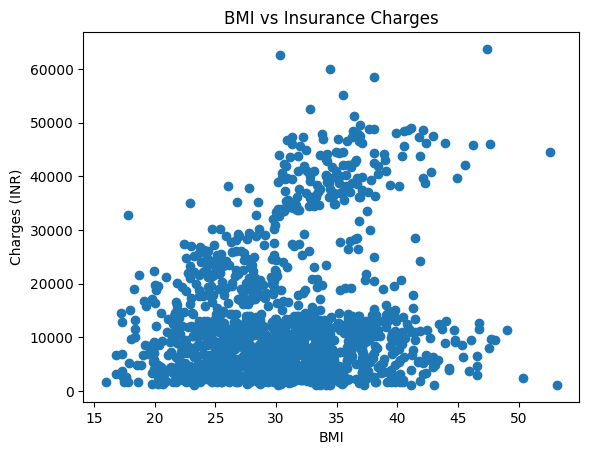

In [32]:
plt.scatter(df_combined['bmi'], df_combined['charges in INR'])
plt.xlabel('BMI')
plt.ylabel('Charges (INR)')
plt.title('BMI vs Insurance Charges')
plt.show()


In [ ]:
# Strong positive correlation → BMI is a risk indicator
# Weak correlation → BMI alone is insufficient

# Ques_6: Does smoking status matter?

In [33]:
# Compare smokers vs non-smokers
df_combined.groupby('smoker')['charges in INR'].mean()


smoker
no      8434.268298
yes    32050.231832
Name: charges in INR, dtype: float64

Smokers claim ~4 times more than non-smokers.

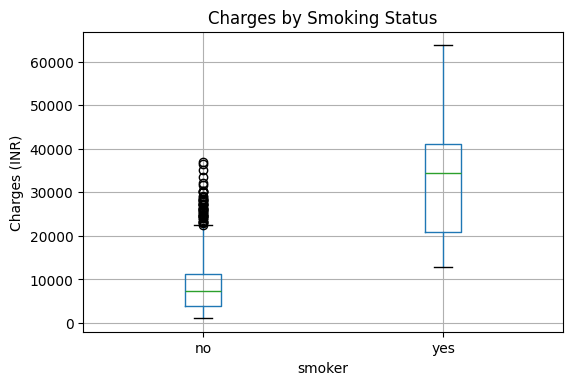

In [34]:
df_combined.boxplot(column='charges in INR', by='smoker', figsize=(6,4))
plt.title('Charges by Smoking Status')
plt.suptitle('')
plt.ylabel('Charges (INR)')
plt.show()


Yes, it is absolutely critical for the company to know whether a person is a smoker.
Smoking should be treated as a major underwriting and pricing factor, with higher premiums or stricter policy terms for smokers.

# Ques_7: Does age act as a barrier for insurance claims?

In [35]:
# Relationship between age and charges
df_combined[['age', 'charges in INR']].corr()


,age,charges in INR
age,1.000000,0.299008
charges in INR,0.299008,1.000000


Correlation between age and charges: 0.299 (moderate positive)

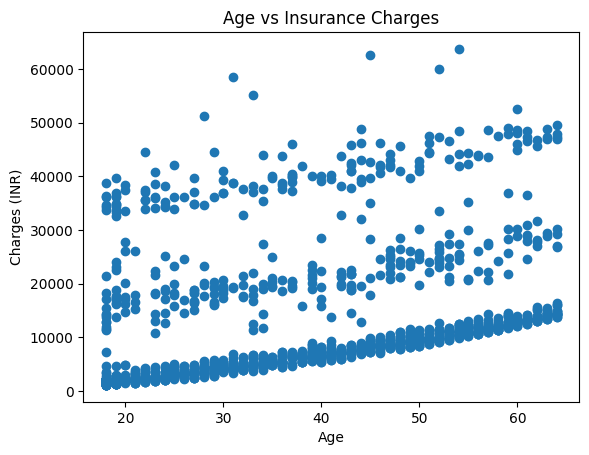

In [36]:
plt.scatter(df_combined['age'], df_combined['charges in INR'])
plt.xlabel('Age')
plt.ylabel('Charges (INR)')
plt.title('Age vs Insurance Charges')
plt.show()


Insurance claims increase steadily with age.
Older age groups show significantly higher medical expenses.

In [38]:
df_combined['age_group'] = pd.cut(df_combined['age'], bins=[18,30,40,50,60,70])
df_combined.groupby('age_group')['charges in INR'].mean()


C:\Users\aniru\AppData\Local\Temp\ipykernel_25220\719088235.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_combined.groupby('age_group')['charges in INR'].mean()


age_group
(18, 30]     9822.837599
(30, 40]    11639.308653
(40, 50]    14782.043077
(50, 60]    17062.292763
(60, 70]    21063.163398
Name: charges in INR, dtype: float64

Age is a strong risk indicator for insurance claims.
While it should not be a barrier to coverage, it should clearly be used for age-based premium adjustments.

# Ques_8: Can discounts be offered based on BMI?

In [39]:
# Compare BMI categories vs charges.
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df_combined['bmi_category'] = df_combined['bmi'].apply(bmi_category)


In [40]:
df_combined.groupby('bmi_category')['charges in INR'].mean()


bmi_category
Normal         10409.337709
Obese          15552.335469
Overweight     10987.509891
Underweight     8852.200585
Name: charges in INR, dtype: float64

Claims increase as BMI moves from normal → overweight → obese
Hence, Yes - BMI can be used to design health-based incentives
Wellness programs or higher premiums for obese customers. BMI should support preventive healthcare pricing, not exclusion

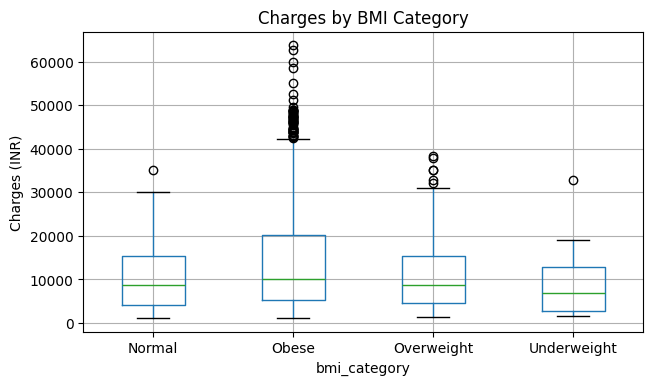

In [41]:
df_combined.boxplot(column='charges in INR', by='bmi_category', figsize=(7,4))
plt.title('Charges by BMI Category')
plt.suptitle('')
plt.ylabel('Charges (INR)')
plt.show()


# CONCLUSION / SUMMARY TABLE

In [42]:
summary = df_combined.groupby(
    ['sex','smoker','region','bmi_category']
)['charges in INR'].mean()

summary


sex     smoker  region     bmi_category
female  no      northeast  Normal           9018.166884
                           Obese           10696.225618
                           Overweight       8412.415992
                           Underweight      6745.586675
                northwest  Normal           7073.507584
                           Obese            9219.742892
                           Overweight       9231.700778
                           Underweight      9817.645075
                southeast  Normal          11198.265056
                           Obese            8541.905587
                           Overweight       7192.363164
                southwest  Normal           6325.958849
                           Obese            8570.907157
                           Overweight       8764.052158
                           Underweight      2156.527000
        yes     northeast  Normal          18646.801563
                           Obese           44238.125938
        

# 🔍 Key Patterns Observed

Smoking dominates all other factors
Smokers with obesity show the highest claim amounts across all genders and regions.

BMI + Smoking is a high-risk combination
Obese smokers consistently cross ₹40,000+ claims.

Non-smokers with normal BMI are lowest risk
Claims mostly below ₹10,000, ideal for discounts.

Gender differences are minimal
Risk is driven more by behavior and health, not sex.

Regional differences exist but are secondary
Southeast shows slightly higher claims but not as impactful as smoking/BMI.